# Springboard Capstone Two: YouTube Trending Videos

In this project, we'll be exploring a global YouTube trending videos dataset to better understand the patterns that characterize highly visible content on the platform.

We'll be utilizing an exploratory and unsupervised approach to uncover any meaninigful structures that push videos into YouTube's "trending" feed. The notebook is structured with the typical ML lifecycle steps we've followed throughout this bootcamp. Through this initial analysis, I hope to establish a more in-depth look on YouTube's engagement metrics, and utilize these deeper patterns for additional YouTube-ML projects in the future.

*Data source*: [Kaggle - canerkonuk/youtube-trending-videos-global](https://www.kaggle.com/datasets/canerkonuk/youtube-trending-videos-global)

In [43]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Since I'm working in WSL, setting MPLCONFIGDIR to a local .matplotlib directory helps with permission issues
os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".matplotlib").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

# Configuring pandas for a chunkier display
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

In [2]:

# Load environment variables from .env file
env_path = Path(".env").expanduser().resolve()
load_dotenv(env_path, override=False)

data_dir = os.getenv("DATA_DIR")
data_file = os.getenv("DATA_FILE")

if not data_dir or not data_file:
    raise ValueError("DATA_DIR and DATA_FILE must both be set in .env before reading the dataset.")

csv_path = Path(data_dir).expanduser() / data_file

if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

## 1. Data Wrangling

The `.csv` file we're working with is absolutely massive, over 18 GB worth and 800,000+ entries! So we're going to try to just load the headers first for now, and then see what fat we can trim off before feeding it into a dataframe.

In [3]:
# Read just the header row to get column names and indices
raw_columns = pd.read_csv(csv_path, nrows=0).columns.tolist()
available_columns = pd.DataFrame({"column_name": raw_columns})

print(f"Found {len(raw_columns)} columns")
available_columns

Found 28 columns


,column_name
0,video_id
1,video_published_at
2,video_trending__date
3,video_trending_country
4,channel_id
5,video_title
6,video_description
7,video_default_thumbnail
8,video_category_id
9,video_tags


Documentation on what each of these columns represent can be found at [YouTube's v3 API documentation](https://developers.google.com/youtube/v3/docs) or the data source.

The API documentation can be a bit tough to decipher, but luckily having worked with the API before I'm fairly familiar with each of these variables.

Some immediate features I would like to **avoid** are:

- `video_trending_country`: We're going to try to avoid country data since it will create too many dummy features.

- `video_title`: We'll avoid any unstructured text data for now since they will require NLP.

- `video_description`

- `video_default_thumbnail`: We'll also be avoiding image data for the same reasons as text data.

- `video_tags`: I imagine this feature could be quite rich in information it provides for us. Unfortunately, it is still text data and would only be able to be realistically processed with NLP, since tags are custom and not selected from some sort of predefined list.

- `video_dimension`: This is actually an interesting feature, since it can be a deterministic feature that seperates regular YouTube content from YouTube shorts. There has also very recently been a change in the platform to support dynamic video dimensions now. But I believe this will likely just add extra noise since the vast majority of content is the same dimension on YouTube.

- `video_definition`

- `channel_title`

- `channel_description`

- `channel_custom_url`

- `channel_country`

- `channel_have_hidden_subscribers`: A strange feature. I believe this is a boolean that indicates if channels have hidden their subscriber count. I haven't encountered any channels that actually do this, but I think this feature would just add noise, so we'll drop it.

- `channel_localized_title`

- `channel_localized_description`

In [4]:
use_cols = [
    "video_id",
    "video_published_at",
    "video_trending__date",
    "channel_id",
    "video_category_id",
    "video_duration",
    "video_licensed_content",
    "video_view_count",
    "video_like_count",
    "video_comment_count",
    "channel_published_at",
    "channel_view_count",
    "channel_subscriber_count",
    "channel_video_count",
]
date_cols = [
    "video_published_at",
    "video_trending__date",
    "channel_published_at",
]

In order to avoid potentially crashing our work environment, we'll be using a combination of the `usecols` parameter to specify which columns we want to load, and the `chunksize` parameter to load the data in smaller chunks. This allows us to work with large subsets of the data without having to load the entire dataset into memory.

In [5]:
chunk_size = 100000
chunks = pd.read_csv(
    csv_path, 
    usecols=use_cols, 
    parse_dates=date_cols, 
    chunksize=chunk_size
    )

In [6]:
chunk = next(chunks)
chunk.head()

,video_id,video_published_at,video_trending__date,channel_id,video_category_id,video_duration,video_licensed_content,video_view_count,video_like_count,video_comment_count,channel_published_at,channel_view_count,channel_subscriber_count,channel_video_count
0,bB3-CUMERIU,2024-10-11 00:00:06+00:00,2024-10-12,UCNYi_zGmR519r5gYdOKLTjQ,Music,PT2M28S,False,20535235.0,2042255.0,152933.0,2021-01-13T06:19:55.86689Z,464615150.0,11600000.0,43.0
1,5ObJt_71AYc,2024-10-11 02:59:21+00:00,2024-10-12,UCzU8-lZlRfkV3nj0RzAZdrQ,Sports,PT10M8S,True,3966042.0,NaN,2549.0,2014-02-19T20:24:31Z,399046746.0,1610000.0,4637.0
2,zfb0whgBBA8,2024-10-11 11:07:25+00:00,2024-10-12,UCgGYPnVJytkr6sVNLQ-l0zQ,Gaming,PT43M24S,True,853167.0,101155.0,10541.0,2012-08-01T16:24:26Z,114331110.0,1380000.0,314.0
3,SJfoPdeOPCQ,2024-10-11 00:10:10+00:00,2024-10-12,UCzU8-lZlRfkV3nj0RzAZdrQ,Sports,PT10M9S,True,3758707.0,NaN,3115.0,2014-02-19T20:24:31Z,399046746.0,1610000.0,4637.0
4,UVb6QOKy0bI,2024-10-09 12:30:27+00:00,2024-10-12,UCOzubmwpVZI7gD0Jf7Bk3Aw,Film & Animation,PT2M12S,True,1730189.0,67522.0,2869.0,2017-05-31T14:31:01Z,19991522.0,40600.0,56.0


In [7]:
chunk.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   video_id                  100000 non-null  str                
 1   video_published_at        100000 non-null  datetime64[us, UTC]
 2   video_trending__date      100000 non-null  datetime64[us]     
 3   channel_id                100000 non-null  str                
 4   video_category_id         99896 non-null   str                
 5   video_duration            100000 non-null  str                
 6   video_licensed_content    100000 non-null  bool               
 7   video_view_count          100000 non-null  float64            
 8   video_like_count          98438 non-null   float64            
 9   video_comment_count       99105 non-null   float64            
 10  channel_published_at      100000 non-null  str                
 11  channel_view

I can already tell that a few features will need cleaning, but I would like to pull in all of the chunks we'll be modifying first so that I can do all of the cleaning in one go. Given that the dataset contains about 800,000 entries, we'll settle for loading in 2 more chunks and work with a subset of 300,000. We'll also space out our selection since it appears that the data is sorted by `video_published_at`.

In [8]:
selected_chunks = [chunk]
target_chunks = {3, 7}

for i, chunk in enumerate(chunks):
    if i in target_chunks:
        selected_chunks.append(chunk)
    if i > max(target_chunks):
        break

df = pd.concat(selected_chunks, ignore_index=True)

In [9]:
# Now let's check out our new dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   video_id                  300000 non-null  str                
 1   video_published_at        300000 non-null  datetime64[us, UTC]
 2   video_trending__date      300000 non-null  datetime64[us]     
 3   channel_id                300000 non-null  str                
 4   video_category_id         299757 non-null  str                
 5   video_duration            300000 non-null  str                
 6   video_licensed_content    300000 non-null  bool               
 7   video_view_count          299977 non-null  float64            
 8   video_like_count          296623 non-null  float64            
 9   video_comment_count       297905 non-null  float64            
 10  channel_published_at      300000 non-null  str                
 11  channel_vie

In [10]:
# channel_published_at had a hard time converting to datetime due to mixed formats, so we'll convert it manually

df["channel_published_at"] = pd.to_datetime(
    df["channel_published_at"], 
    utc=True,
    format="ISO8601"
)

df["channel_published_at"].head()

0   2021-01-13 06:19:55.866890+00:00
1          2014-02-19 20:24:31+00:00
2          2012-08-01 16:24:26+00:00
3          2014-02-19 20:24:31+00:00
4          2017-05-31 14:31:01+00:00
Name: channel_published_at, dtype: datetime64[us, UTC]

In [11]:
df.rename(columns={"video_trending__date": "video_trending_date"}, inplace=True)
df.head()

,video_id,video_published_at,video_trending_date,channel_id,video_category_id,video_duration,video_licensed_content,video_view_count,video_like_count,video_comment_count,channel_published_at,channel_view_count,channel_subscriber_count,channel_video_count
0,bB3-CUMERIU,2024-10-11 00:00:06+00:00,2024-10-12,UCNYi_zGmR519r5gYdOKLTjQ,Music,PT2M28S,False,20535235.0,2042255.0,152933.0,2021-01-13 06:19:55.866890+00:00,464615150.0,11600000.0,43.0
1,5ObJt_71AYc,2024-10-11 02:59:21+00:00,2024-10-12,UCzU8-lZlRfkV3nj0RzAZdrQ,Sports,PT10M8S,True,3966042.0,NaN,2549.0,2014-02-19 20:24:31+00:00,399046746.0,1610000.0,4637.0
2,zfb0whgBBA8,2024-10-11 11:07:25+00:00,2024-10-12,UCgGYPnVJytkr6sVNLQ-l0zQ,Gaming,PT43M24S,True,853167.0,101155.0,10541.0,2012-08-01 16:24:26+00:00,114331110.0,1380000.0,314.0
3,SJfoPdeOPCQ,2024-10-11 00:10:10+00:00,2024-10-12,UCzU8-lZlRfkV3nj0RzAZdrQ,Sports,PT10M9S,True,3758707.0,NaN,3115.0,2014-02-19 20:24:31+00:00,399046746.0,1610000.0,4637.0
4,UVb6QOKy0bI,2024-10-09 12:30:27+00:00,2024-10-12,UCOzubmwpVZI7gD0Jf7Bk3Aw,Film & Animation,PT2M12S,True,1730189.0,67522.0,2869.0,2017-05-31 14:31:01+00:00,19991522.0,40600.0,56.0


There are still a few features left to clean:
- `video_id` and `channel_id` are not ideal as strings. I think they will likely get dropped, but I want to do a bit of exploring before we get rid of them, since I'm curious to see if there are any repeating values.
- `video_category_id` is an interesting one. I know from my experience with a previous project that there are already enumerated values we can use for these.
- `video_duration` is formatted as periodtime ISO 8601, resulting in a string. We'll have to convert that one to a numerical value, likely in total seconds.
- `video_licensed_content` can be converted to binary.

In [12]:
# Converting `video_licensed_content` to binary
df["video_licensed_content"] = df["video_licensed_content"].astype(int)

In [13]:
# Converting video_duration from ISO 8601 format to total seconds
def parse_iso8601_duration(duration_str):
    if pd.isna(duration_str):
        return np.nan
    
    duration_str = duration_str.replace("PT", "")
    hours, minutes, seconds = 0, 0, 0
    
    if "H" in duration_str:
        hours = int(duration_str.split("H")[0])
        duration_str = duration_str.split("H")[1] if "H" in duration_str else ""
    
    if "M" in duration_str:
        minutes = int(duration_str.split("M")[0])
        duration_str = duration_str.split("M")[1] if "M" in duration_str else ""
    
    if "S" in duration_str:
        seconds = int(duration_str.split("S")[0])
    
    total_seconds = hours * 3600 + minutes * 60 + seconds
    return total_seconds

In [14]:
df['video_duration_seconds'] = df['video_duration'].apply(parse_iso8601_duration)
df.drop(columns=['video_duration'], inplace=True)

The following category dictionary can be obtained via the YouTube API. Since I don't really want to mess around with APIs in this Notebook, I'm just copy/pasting it from my previous project.

In [15]:
category_df = pd.DataFrame(
    [
        {"id": 1, "title": "Film & Animation", "assignable": True},
        {"id": 2, "title": "Autos & Vehicles", "assignable": True},
        {"id": 10, "title": "Music", "assignable": True},
        {"id": 15, "title": "Pets & Animals", "assignable": True},
        {"id": 17, "title": "Sports", "assignable": True},
        {"id": 18, "title": "Short Movies", "assignable": False},
        {"id": 19, "title": "Travel & Events", "assignable": True},
        {"id": 20, "title": "Gaming", "assignable": True},
        {"id": 21, "title": "Videoblogging", "assignable": False},
        {"id": 22, "title": "People & Blogs", "assignable": True},
        {"id": 23, "title": "Comedy", "assignable": True},
        {"id": 24, "title": "Entertainment", "assignable": True},
        {"id": 25, "title": "News & Politics", "assignable": True},
        {"id": 26, "title": "Howto & Style", "assignable": True},
        {"id": 27, "title": "Education", "assignable": True},
        {"id": 28, "title": "Science & Technology", "assignable": True},
        {"id": 29, "title": "Nonprofits & Activism", "assignable": True},
        {"id": 30, "title": "Movies", "assignable": False},
        {"id": 31, "title": "Anime/Animation", "assignable": False},
        {"id": 32, "title": "Action/Adventure", "assignable": False},
        {"id": 33, "title": "Classics", "assignable": False},
        {"id": 34, "title": "Comedy", "assignable": False},
        {"id": 35, "title": "Documentary", "assignable": False},
        {"id": 36, "title": "Drama", "assignable": False},
        {"id": 37, "title": "Family", "assignable": False},
        {"id": 38, "title": "Foreign", "assignable": False},
        {"id": 39, "title": "Horror", "assignable": False},
        {"id": 40, "title": "Sci-Fi/Fantasy", "assignable": False},
        {"id": 41, "title": "Thriller", "assignable": False},
        {"id": 42, "title": "Shorts", "assignable": False},
        {"id": 43, "title": "Shows", "assignable": False},
        {"id": 44, "title": "Trailers", "assignable": False},
    ]
)

Interestingly, "Comedy" appears twice as a category. It seems there is one for when `assignable` is True and a different one for when it's false. My intution tells me that the `assignable = False` id is for licensed content. Let's have a quick look.

In [16]:
categories = df['video_category_id'].unique()
categories

<StringArray>
[               'Music',               'Sports',               'Gaming',
     'Film & Animation',       'People & Blogs',        'Entertainment',
      'News & Politics',               'Comedy',        'Howto & Style',
            'Education',      'Travel & Events',       'Pets & Animals',
 'Science & Technology',                    nan,     'Autos & Vehicles']
Length: 15, dtype: str

In [17]:
licensed_comedy_count = (
    df.loc[df['video_category_id'] == "Comedy", 'video_licensed_content']
    .value_counts(dropna=False)
    .sort_index(ascending=False)
)
licensed_comedy_count

video_licensed_content
1    16026
0      472
Name: count, dtype: int64

In [18]:
assignable_category_lookup = (
    category_df.loc[category_df['assignable'], ['title', 'id']]
    .drop_duplicates(subset='title')
    .set_index('title')['id']
)

df['category_id'] = df['video_category_id'].map(assignable_category_lookup)

comedy_mask = df['video_category_id'].eq("Comedy")
df.loc[comedy_mask, 'category_id'] = np.where(
    df.loc[comedy_mask, 'video_licensed_content'].eq(1),
    34,
    23,
)

df['category_id'] = df['category_id'].astype('Int64')
df[['video_category_id', 'category_id']].head()

,video_category_id,category_id
0,Music,10
1,Sports,17
2,Gaming,20
3,Sports,17
4,Film & Animation,1


We'll keep the original `video_category_id` for now for EDA purposes, but we'll drop it later in preprocessing.

In [19]:
# Final check of the dataframe
df.head()

,video_id,video_published_at,video_trending_date,channel_id,video_category_id,video_licensed_content,video_view_count,video_like_count,video_comment_count,channel_published_at,channel_view_count,channel_subscriber_count,channel_video_count,video_duration_seconds,category_id
0,bB3-CUMERIU,2024-10-11 00:00:06+00:00,2024-10-12,UCNYi_zGmR519r5gYdOKLTjQ,Music,0,20535235.0,2042255.0,152933.0,2021-01-13 06:19:55.866890+00:00,464615150.0,11600000.0,43.0,148,10
1,5ObJt_71AYc,2024-10-11 02:59:21+00:00,2024-10-12,UCzU8-lZlRfkV3nj0RzAZdrQ,Sports,1,3966042.0,NaN,2549.0,2014-02-19 20:24:31+00:00,399046746.0,1610000.0,4637.0,608,17
2,zfb0whgBBA8,2024-10-11 11:07:25+00:00,2024-10-12,UCgGYPnVJytkr6sVNLQ-l0zQ,Gaming,1,853167.0,101155.0,10541.0,2012-08-01 16:24:26+00:00,114331110.0,1380000.0,314.0,2604,20
3,SJfoPdeOPCQ,2024-10-11 00:10:10+00:00,2024-10-12,UCzU8-lZlRfkV3nj0RzAZdrQ,Sports,1,3758707.0,NaN,3115.0,2014-02-19 20:24:31+00:00,399046746.0,1610000.0,4637.0,609,17
4,UVb6QOKy0bI,2024-10-09 12:30:27+00:00,2024-10-12,UCOzubmwpVZI7gD0Jf7Bk3Aw,Film & Animation,1,1730189.0,67522.0,2869.0,2017-05-31 14:31:01+00:00,19991522.0,40600.0,56.0,132,1


# 2. Exploratory Data Analysis

Let's start by taking a closer look at our missing values.

,missing_count,missing_percent
video_like_count,3377,1.13
video_comment_count,2095,0.70
video_category_id,243,0.08
category_id,243,0.08
video_view_count,23,0.01


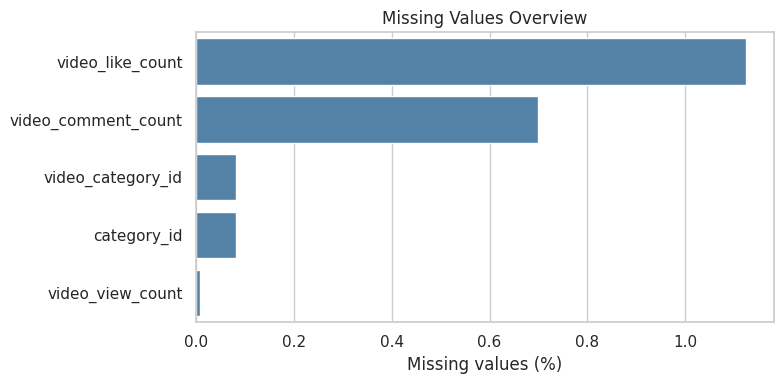

In [20]:
missing_count = df.isna().sum()
missing_percent = missing_count / len(df) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent,
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values("missing_count", ascending=False)


display(missing_summary.round(2))

missing_plot = missing_summary.reset_index(names="column").head(10)
plt.figure(figsize=(8, 4))
sns.barplot(data=missing_plot, x="missing_percent", y="column", color="steelblue")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.title("Missing Values Overview")
plt.tight_layout()
plt.show()

Luckily, missing features like `video_like_count`, `video_comment_count`, and `video_view_count` aren't of much concern due to their numerical nature. We can consider an imputation process for each of these later. The missing `category_id` values may be worth taking a closer look at. 

Right now I'm considering potentially dropping rows that pertain to certain categories to perhaps refine our model's categorization potential. But first, let's get an overview on the category distribution.

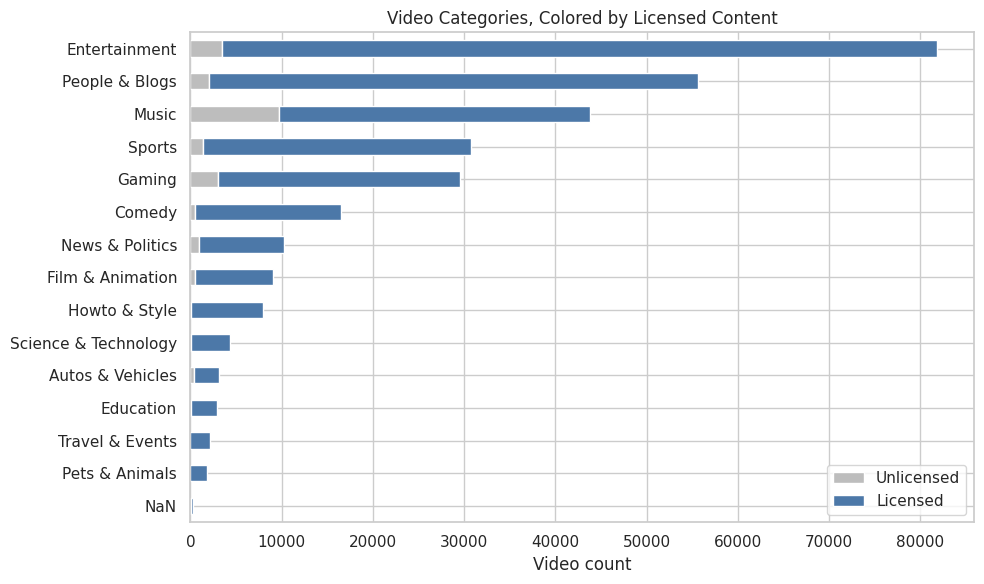

video_licensed_content,Licensed,Unlicensed,Total,unlicensed_percent
video_category_id,,,,
Entertainment,78307,3483,81790,4.26
People & Blogs,53561,2037,55598,3.66
Music,34075,9753,43828,22.25
Sports,29336,1419,30755,4.61
Gaming,26497,3064,29561,10.37
Comedy,16026,472,16498,2.86
News & Politics,9296,965,10261,9.40
Film & Animation,8593,467,9060,5.15
Howto & Style,7942,55,7997,0.69


In [21]:

category_labels = df["video_category_id"].fillna("NaN")

category_license = pd.crosstab(
    category_labels,
    df["video_licensed_content"],
)

category_license = category_license.rename(columns={0: "Unlicensed", 1: "Licensed"})

category_license = category_license[["Unlicensed", "Licensed"]]
category_license["Total"] = category_license["Unlicensed"] + category_license["Licensed"]
category_license["unlicensed_percent"] = (
    category_license["Unlicensed"] / category_license["Total"] * 100
)
category_license = category_license.sort_values("Total")

category_license[["Unlicensed", "Licensed"]].plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6),
    color=["#bdbdbd", "#4c78a8"],
)
plt.xlabel("Video count")
plt.ylabel("")
plt.title("Video Categories, Colored by Licensed Content")
plt.legend(title="")
plt.tight_layout()
plt.show()

display(
    category_license.sort_values("Total", ascending=False)
    [["Licensed", "Unlicensed", "Total", "unlicensed_percent"]]
    .round(2)
)

This distribution actually caught me by surprise. I was operating under the presumption that licensed content was reserved for only production studios, i.e. TV networks, music labels, etc. I went ahead and referenced the YouTube API documentation to find out that any content uploaded by a YouTube partner (aka any channel that can run ads) counts as licensed content.

For this reason I think it's worth keeping both licensed and unlicensed content. It is likely that our model may pick up on unlicensed content as a grouping that is less likely to be trending.

We should also just drop the rows with no `category_id` since there are so few.

In [22]:
# Drop rows with missing category_id
df = df.dropna(subset=['video_category_id'])
df.info()

<class 'pandas.DataFrame'>
Index: 299757 entries, 0 to 299999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   video_id                  299757 non-null  str                
 1   video_published_at        299757 non-null  datetime64[us, UTC]
 2   video_trending_date       299757 non-null  datetime64[us]     
 3   channel_id                299757 non-null  str                
 4   video_category_id         299757 non-null  str                
 5   video_licensed_content    299757 non-null  int64              
 6   video_view_count          299734 non-null  float64            
 7   video_like_count          296394 non-null  float64            
 8   video_comment_count       297676 non-null  float64            
 9   channel_published_at      299757 non-null  datetime64[us, UTC]
 10  channel_view_count        299757 non-null  float64            
 11  channel_subscrib

Next, I want to check the `video_id` and `channel_id` behavior before deciding how to approach them. I'm curious to see how frequently the same channel makes an appearance on trending, or even the same video.


In [23]:
id_summary = []

for col in ["video_id", "channel_id"]:
    counts = df[col].value_counts()
    id_summary.append(
        {
            "feature": col,
            "unique_values": counts.size,
            "total_values": df[col].size,
            "percent_duplicated": (1 - counts.size / df[col].size) * 100,
            "mean_rows_per_id": counts.mean(),
            "median_rows_per_id": counts.median(),
            "95th_percentile_rows_per_id": counts.quantile(0.95),
        }
    )

id_summary = pd.DataFrame(id_summary)
display(id_summary.round(2))


,feature,unique_values,total_values,percent_duplicated,mean_rows_per_id,median_rows_per_id,95th_percentile_rows_per_id
0,video_id,21084,299757,92.97,14.22,6.0,67.0
1,channel_id,10262,299757,96.58,29.21,8.0,110.0


Wow! Both IDs repeat way more than I expected. My suspicion for why this may be the case is due to the dataset covering multiple countries, and so any video that is being featured as trending in one country may be repeated for trending in another.

I'm inclined to not include either feature in the dataset. However, I also believe it's worth dropping all duplicated `video_id` values. If we include these many duplicates of the same video, the model will be drowned in the noise of patterns for identifying the same exact video, and won't actually learn anything useful for us. We'll be left with much fewer entries, but still a fair amount.


In [24]:
rows_before = len(df)

df = df.drop_duplicates(subset="video_id").copy()
df = df.reset_index(drop=True)

print(f"Rows before pruning: {rows_before}")
print(f"Rows after pruning: {len(df)}")

Rows before pruning: 299757
Rows after pruning: 21084


In [25]:
# Lets drop both ID columns
df.drop(columns=["video_id", "channel_id"], inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21084 entries, 0 to 21083
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   video_published_at        21084 non-null  datetime64[us, UTC]
 1   video_trending_date       21084 non-null  datetime64[us]     
 2   video_category_id         21084 non-null  str                
 3   video_licensed_content    21084 non-null  int64              
 4   video_view_count          21081 non-null  float64            
 5   video_like_count          20784 non-null  float64            
 6   video_comment_count       20861 non-null  float64            
 7   channel_published_at      21084 non-null  datetime64[us, UTC]
 8   channel_view_count        21084 non-null  float64            
 9   channel_subscriber_count  21084 non-null  float64            
 10  channel_video_count       21084 non-null  float64            
 11  video_duration_seconds    

We're gonna add a couple numerical features that I think should prove helpful with our analysis, and get us out of using datetime values: `days_to_trend` and `channel_age_years`.

In [26]:

days_trending = pd.to_datetime(df["video_trending_date"], utc=True)
days_published = pd.to_datetime(df["video_published_at"], utc=True)
df["days_to_trend"] = (days_trending - days_published).dt.total_seconds() / 86400


channel_trending = pd.to_datetime(df["video_trending_date"], utc=True)
channel_published = pd.to_datetime(df["channel_published_at"], utc=True)
df["channel_age_years"] = (
    (channel_trending - channel_published).dt.total_seconds() / (365.25 * 24 * 60 * 60)
)

Alright, let's look at the distributions. For the numeric features, the raw values ended up being extremely right-skewed, so I ended up plotting scaled `log1p` versions of the counts alongside the timing features.

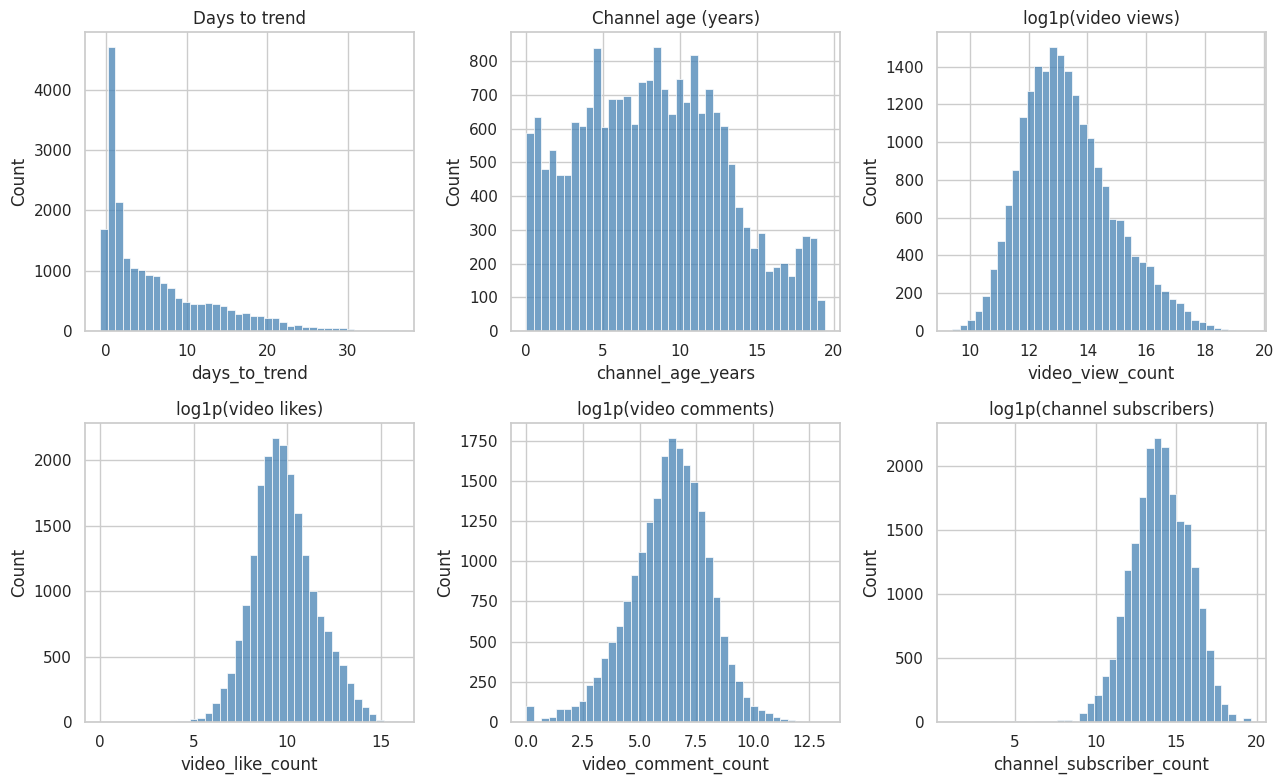

In [27]:
dist_specs = [
    ("days_to_trend", "Days to trend", False),
    ("channel_age_years", "Channel age (years)", False),
    ("video_view_count", "log1p(video views)", True),
    ("video_like_count", "log1p(video likes)", True),
    ("video_comment_count", "log1p(video comments)", True),
    ("channel_subscriber_count", "log1p(channel subscribers)", True),
]
dist_specs = [spec for spec in dist_specs if spec[0] in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for ax, (col, title, use_log) in zip(axes, dist_specs):
    series = df[col].dropna()
    if use_log:
        series = np.log1p(series)
    sns.histplot(series, bins=40, ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_ylabel("Count")

for ax in axes[len(dist_specs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Let's look at correlation values. A few values I want to keep an eye on are:
- `video_view_count`, `video_like_count`, and `video_comment_count`. If they are correlated any more than 0.7, we should drop them and only keep one.
- `channel_view_count` and `channel_subscriber_count`. Same deal, if they're too correlated, let's keep one and ditch the other.

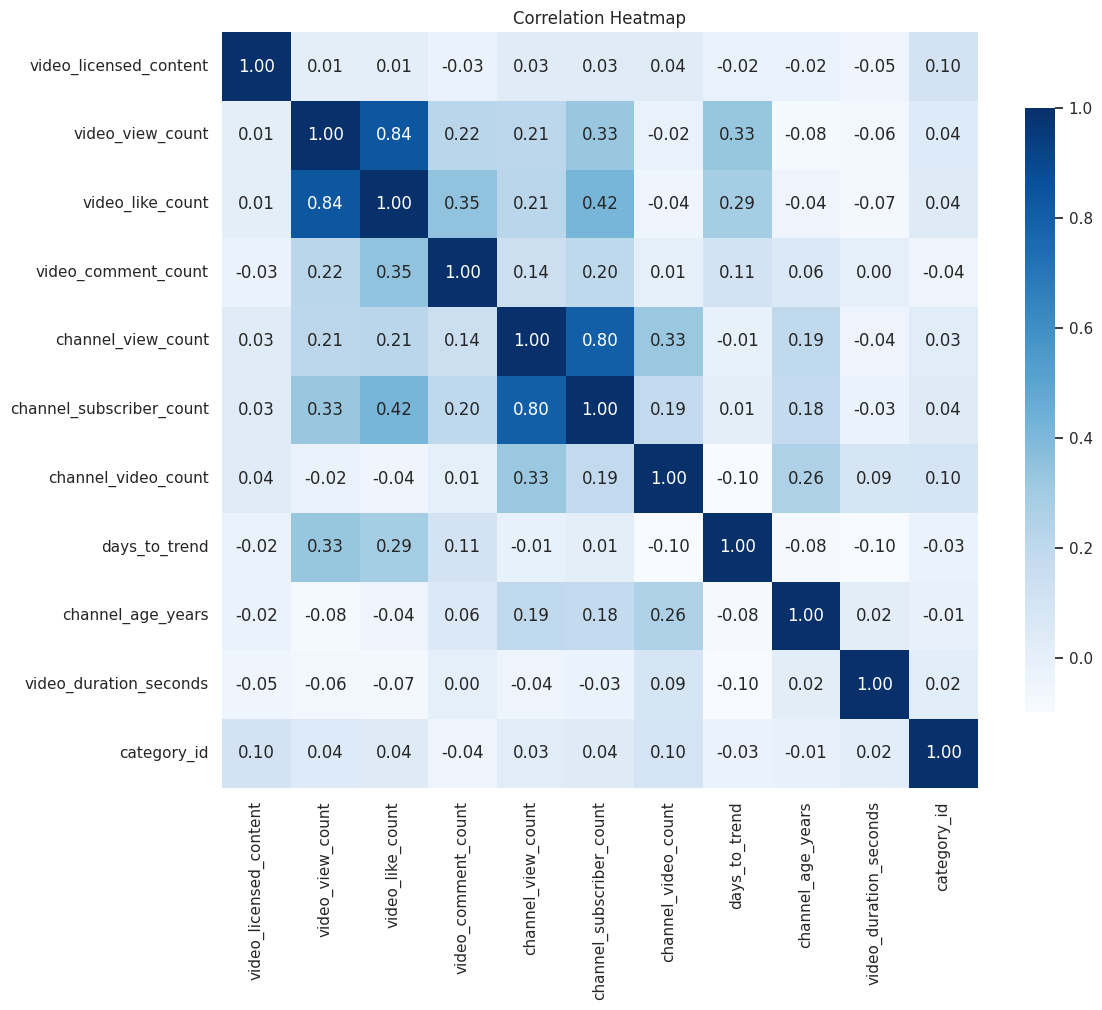

In [28]:
corr_cols = [
    "video_licensed_content",
    "video_view_count",
    "video_like_count",
    "video_comment_count",
    "channel_view_count",
    "channel_subscriber_count",
    "channel_video_count",
    "days_to_trend",
    "channel_age_years",
    "video_duration_seconds",
    "category_id",
    ]

plt.figure(figsize=(12, 10))
sns.heatmap(
    df[corr_cols].dropna().corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


So we see a pretty distinct correlation between `video_view_count` and `video_like_count`. However, surprisingly not so much with `video_comment_count`. It seems like comments correlate slightly more strongly with like count, which makes sense since they're both additional steps of engagement beyond viewership. Because of this, I think it would be best to keep both `video_view_count` and `video_comment_count`.

`channel_view_count` and `channel_subscriber_count` are also strongly correlated. I think we'll drop `channel_view_count` since it has less correlation with other features.

Some other noteworthy correlations:
- `video_like_count` and `channel_subscriber_count` have a correlation of 0.42, indicating high subscriber counts may be indicative of a more engaged audience.
- `video_view_count` and `days_to_trend` have a correlation of 0.33, which is too slight to draw any earnest conclusions, but I would hypothesize that this perhaps means YouTube's other algorithms that drive view count, such as the home page or suggestion tab, are likely driven by the same underlying metrics that the trending page is.

Finally, I want to do a final analysis on video categories. It had an absurdly weak correlation of -0.03 with `days_to_trend`, but I believe that we can still benefit from a comparative boxplot between categories.

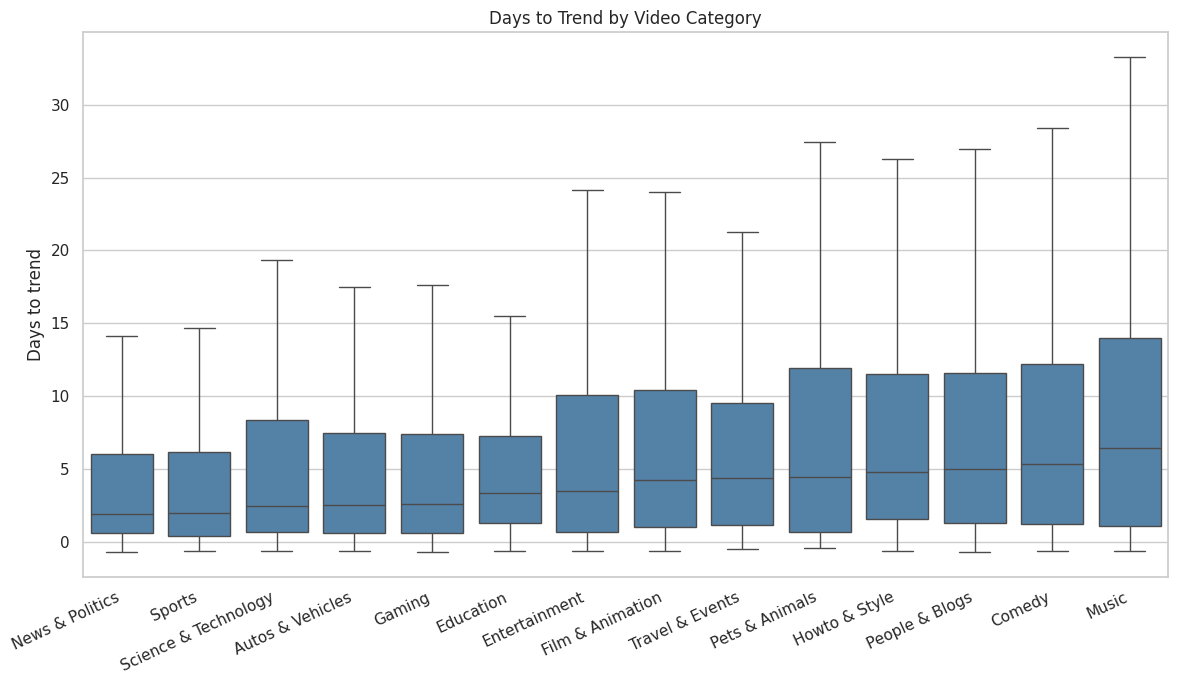

In [29]:
trend_plot_df = df[["video_category_id", "days_to_trend"]].dropna().copy()
order = (
    trend_plot_df.groupby("video_category_id")["days_to_trend"]
    .median()
    .sort_values()
    .index
)

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=trend_plot_df,
    x="video_category_id",
    y="days_to_trend",
    order=order,
    color="steelblue",
    showfliers=False,
)
plt.xlabel("")
plt.ylabel("Days to trend")
plt.title("Days to Trend by Video Category")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 3. Preprocessing & Feature Engineering

Let's first make sure we clean up any remaining features that we won't be using in our final modeling stage.

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21084 entries, 0 to 21083
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   video_published_at        21084 non-null  datetime64[us, UTC]
 1   video_trending_date       21084 non-null  datetime64[us]     
 2   video_category_id         21084 non-null  str                
 3   video_licensed_content    21084 non-null  int64              
 4   video_view_count          21081 non-null  float64            
 5   video_like_count          20784 non-null  float64            
 6   video_comment_count       20861 non-null  float64            
 7   channel_published_at      21084 non-null  datetime64[us, UTC]
 8   channel_view_count        21084 non-null  float64            
 9   channel_subscriber_count  21084 non-null  float64            
 10  channel_video_count       21084 non-null  float64            
 11  video_duration_seconds    

In [ ]:
df.drop(columns=[
    'video_published_at', 
    'video_trending_date', 
    'video_category_id',
    'video_like_count',
    'channel_published_at',
    'channel_view_count'
    ], inplace=True)

I originally considered using an imputation method to account for the rows that are missing vlaues for `video_view_count` and `video_comment_count`, but given that these values proved to be heavily skewed when we plotted the histogram, I worry that using an imputation (even a median value) may distort the structure of the clusters. It's also a very negligble amount of rows being dropped.

In [34]:
df.dropna(subset=['video_view_count', 'video_comment_count'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 20861 entries, 0 to 21083
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   video_licensed_content    20861 non-null  int64  
 1   video_view_count          20861 non-null  float64
 2   video_comment_count       20861 non-null  float64
 3   channel_subscriber_count  20861 non-null  float64
 4   channel_video_count       20861 non-null  float64
 5   video_duration_seconds    20861 non-null  int64  
 6   category_id               20861 non-null  Int64  
 7   days_to_trend             20861 non-null  float64
 8   channel_age_years         20861 non-null  float64
dtypes: Int64(1), float64(6), int64(2)
memory usage: 1.6 MB


Looking back on the correlation map, we saw `video_comment_count` actually had a stronger correlation with `video_like_count` than it did with `video_view_count`. This means comments are an interesting metric of engagement. Someone who watches a video isn't necessarily going to like or comment, but the additional step of engagement between liking a video and commenting is sort of similar.

Because of this, I would like to create a sort of "engagement ratio" feature that we can use to observe to potentially differentiate videos purely on the vector of engagement, normalized over viewership. We'll do number of comments per 1,000 views.

In [38]:
df["comments_per_1k_views"] = (
    df["video_comment_count"] / df["video_view_count"].clip(lower=1) * 1000
)

As we found out from the distribution plot, a few of the numerical features trend towards having a power log right skew, which intuitively makes sense. We want to do a bit of preprocessing here simple and add `log1p` versions of the most skewed features. We should also test a few bucketed versions of `category_id`, but only as a brief preprocessing check before the actual modeling process.

In [46]:
skew_check = (
    df[
        [
            "video_view_count",
            "video_comment_count",
            "channel_subscriber_count",
            "channel_video_count",
            "video_duration_seconds",
            "days_to_trend",
            "channel_age_years",
            "comments_per_1k_views",
        ]
    ]
    .skew()
    .sort_values(ascending=False)
    .round(2)
)

print("Skew check")
print(skew_check.to_string())

Skew check
video_comment_count         24.33
channel_subscriber_count    12.80
video_view_count            10.21
channel_video_count          6.66
video_duration_seconds       6.22
comments_per_1k_views        4.65
days_to_trend                1.38
channel_age_years            0.23


Turns out more features than I initially thought are pretty heavily skewed. Even video duration seems like it could benefit from log compression.

In [48]:
for col in [
    "video_view_count",
    "video_comment_count",
    "channel_subscriber_count",
    "channel_video_count",
    "video_duration_seconds",
    "comments_per_1k_views",
]:
    df[f"log_{col}"] = np.log1p(df[col])

df.head()

,video_licensed_content,video_view_count,video_comment_count,channel_subscriber_count,channel_video_count,video_duration_seconds,category_id,days_to_trend,channel_age_years,comments_per_1k_views,log_video_view_count,log_video_comment_count,log_channel_subscriber_count,log_channel_video_count,log_video_duration_seconds,top_categories_bucket_3,top_categories_bucket_5,top_categories_bucket_10,top_categories_bucket_13,top_categories_bucket_15,log_comments_per_1k_views
0,0,20535235.0,152933.0,11600000.0,43.0,148,10,0.999931,3.744658,7.447346,16.837653,11.937762,16.266516,3.784190,5.003946,10,10,10,10,10,2.133852
1,1,3966042.0,2549.0,1610000.0,4637.0,608,17,0.875451,10.642436,0.642706,15.193279,7.843849,14.291745,8.442039,6.411818,-1,17,17,17,17,0.496345
2,1,853167.0,10541.0,1380000.0,314.0,2604,20,0.536516,12.195254,12.355143,13.656712,9.263123,14.137595,5.752573,7.865188,-1,20,20,20,20,2.591902
3,1,3758707.0,3115.0,1610000.0,4637.0,609,17,0.992940,10.642436,0.828742,15.139586,8.044305,14.291745,8.442039,6.413459,-1,17,17,17,17,0.603629
4,1,1730189.0,2869.0,40600.0,56.0,132,1,2.478854,7.365900,1.658200,14.363742,7.962067,10.611548,4.043051,4.890349,-1,-1,1,1,1,0.977649


In [42]:
category_counts = df["category_id"].value_counts()

for top_n in [3, 5, 10, 13, 15]:
    top_categories = category_counts.head(top_n).index
    df[f"top_categories_bucket_{top_n}"] = np.where(
        df["category_id"].isin(top_categories),
        df["category_id"],
        -1, # Using "-1" to indicate "other" category
    )

print("Category counts")
print(category_counts.to_string())

Category counts
category_id
24    5947
22    3346
10    2588
17    2321
20    1750
25    1364
34    1146
1      696
26     483
2      324
27     302
28     289
19     173
15      97
23      35


Rather than building a full search here, I'll do a very small KMeans probe across the different top-N category buckets. This is only a quick preprocessing check to see which bucket size looks reasonable before the real clustering work later on.


In [ ]:
# K range and bucket choices are frankly arbitrary, but I want to see how the 
# clustering metrics look across a few different values for each
k_range = range(2, 9)
bucket_choices = [3, 5, 10, 13, 15]

log_numeric_cols = [
    "video_licensed_content",
    "log_video_view_count",
    "log_video_comment_count",
    "log_channel_subscriber_count",
    "log_channel_video_count",
    "log_video_duration_seconds",
    "log_comments_per_1k_views",
    "days_to_trend",
    "channel_age_years",
]

probe_df = df[
    log_numeric_cols + [f"top_categories_bucket_{n}" for n in bucket_choices]
].dropna().copy()

# If we don't do a sample size, the clustering metrics take a very long time to compute.
probe_df = probe_df.sample(5000, random_state=42)

bucket_probe_results = []

for top_n in bucket_choices:
    X_probe = pd.concat(
        [
            probe_df[log_numeric_cols],
            pd.get_dummies(probe_df[f"top_categories_bucket_{top_n}"], prefix="category"),
        ],
        axis=1,
    )
    X_probe_scaled = StandardScaler().fit_transform(X_probe)

    for k in range(2, 9):
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_probe_scaled)
        bucket_probe_results.append(
            {
                "top_n": top_n,
                "k": k,
                "silhouette": silhouette_score(X_probe_scaled, labels),
                "calinski_harabasz": calinski_harabasz_score(X_probe_scaled, labels),
                "davies_bouldin": davies_bouldin_score(X_probe_scaled, labels),
            }
        )

bucket_probe_results = pd.DataFrame(bucket_probe_results)

bucket_probe_summary = (
    bucket_probe_results.groupby("top_n")
    .agg(
        best_silhouette=("silhouette", "max"),
        best_calinski_harabasz=("calinski_harabasz", "max"),
        best_davies_bouldin=("davies_bouldin", "min"),
    )
    .sort_index()
    .round(3)
)

bucket_probe_summary

,best_silhouette,best_calinski_harabasz,best_davies_bouldin
top_n,,,
3,0.240,850.697,1.458
5,0.281,753.205,1.406
10,0.268,530.067,1.701
13,0.267,418.729,1.975
15,0.237,389.866,1.678


`top_n = 5` seems like the immediate best choice just purely for scoring best in 2 out of the 3 metrics. It gave the best silhouette score and the best Davies-Bouldin score. However, the second best option of `top_n = 3` is fairly comparable. Both have notably iffy silhouette scores. `top_n = 5` has a somewhat better *davies bouldin* score, suggesting that it provides more distinct clusters. 

We'll use `n = 5` for the sake of simplicity.

In [41]:
top_n = 5
final_category_col = f"top_categories_bucket_{top_n}"
final_top_category_ids = category_counts.head(top_n).index.tolist()


# I actually feel a bit foolish now for insisting on keeping categories numerical,
# since we're using dummy features for each of them anyways.

# So, time to convert them back for readibility.
final_top_categories = (
    category_df.set_index("id").loc[final_top_category_ids, "title"]
    .str.lower()
    .str.replace(" & ", "_and_", regex=False)
    .str.replace(" ", "_", regex=False)
    .tolist()
    + ["other"]
)

final_top_categories

['entertainment', 'people_and_blogs', 'music', 'sports', 'gaming', 'other']

In [42]:
final_category_map = dict(zip(final_top_category_ids, final_top_categories[:-1]))

final_category_series = df[final_category_col].map(final_category_map).fillna("other")
final_category_series = final_category_series.astype(
    pd.CategoricalDtype(categories=final_top_categories)
)

category_dummies = pd.get_dummies(final_category_series, prefix="category", dtype=int)
category_dummies.head()

,category_entertainment,category_people_and_blogs,category_music,category_sports,category_gaming,category_other
0,0,0,1,0,0,0
1,0,0,0,1,0,0
2,0,0,0,0,1,0
3,0,0,0,1,0,0
4,0,0,0,0,0,1


In [43]:
# Cross referencing the original category ID as a sanity check
df['category_id'].head()

0    10
1    17
2    20
3    17
4     1
Name: category_id, dtype: Int64

In [49]:
final_continuous_cols = [
    "log_video_view_count",
    "log_video_comment_count",
    "log_channel_subscriber_count",
    "log_channel_video_count",
    "log_video_duration_seconds",
    "log_comments_per_1k_views",
    "days_to_trend",
    "channel_age_years",
]

final_binary_cols = ["video_licensed_content"]

X_final = pd.concat(
    [df[final_continuous_cols + final_binary_cols], category_dummies],
    axis=1,
)

X_final_scaled = X_final.copy()
scaler = StandardScaler()
X_final_scaled[final_continuous_cols] = scaler.fit_transform(X_final[final_continuous_cols])

display(X_final.head())
display(X_final_scaled.head())

,log_video_view_count,log_video_comment_count,log_channel_subscriber_count,log_channel_video_count,log_video_duration_seconds,log_comments_per_1k_views,days_to_trend,channel_age_years,video_licensed_content,category_entertainment,category_people_and_blogs,category_music,category_sports,category_gaming,category_other
0,16.837653,11.937762,16.266516,3.784190,5.003946,2.133852,0.999931,3.744658,0,0,0,1,0,0,0
1,15.193279,7.843849,14.291745,8.442039,6.411818,0.496345,0.875451,10.642436,1,0,0,0,1,0,0
2,13.656712,9.263123,14.137595,5.752573,7.865188,2.591902,0.536516,12.195254,1,0,0,0,0,1,0
3,15.139586,8.044305,14.291745,8.442039,6.413459,0.603629,0.992940,10.642436,1,0,0,0,1,0,0
4,14.363742,7.962067,10.611548,4.043051,4.890349,0.977649,2.478854,7.365900,1,0,0,0,0,0,1


,log_video_view_count,log_video_comment_count,log_channel_subscriber_count,log_channel_video_count,log_video_duration_seconds,log_comments_per_1k_views,days_to_trend,channel_age_years,video_licensed_content,category_entertainment,category_people_and_blogs,category_music,category_sports,category_gaming,category_other
0,2.249888,3.237752,1.244539,-1.607615,-0.458861,1.747857,-0.758889,-0.950259,0,0,0,1,0,0,0
1,1.187170,0.886737,0.156682,0.811391,0.305341,-0.574535,-0.776886,0.505657,1,0,0,0,1,0,0
2,0.194124,1.701785,0.071764,-0.585355,1.094239,2.397484,-0.825887,0.833411,1,0,0,0,0,1,0
3,1.152469,1.001854,0.156682,0.811391,0.306231,-0.422380,-0.759900,0.505657,1,0,0,0,1,0,0
4,0.651060,0.954627,-1.870656,-1.473177,-0.520522,0.108074,-0.545074,-0.185923,1,0,0,0,0,0,1
